## Charging Stations

1. CS point diagram, 3 colours - 3 CS types.
2. EV area distribution, for each EV type, draw one individual diagram

In [1]:
import math
import requests
import pandas as pd

url = "https://api.openchargemap.io/v3/poi/"
params = {
    "output": "json",
    "countrycode": "GB",
    "maxresults": 500000,
    "key": "5be57c4b-dd03-4ea8-800d-1b4b37f5cbd8",
}

resp = requests.get(url, params=params, timeout=120)
resp.raise_for_status()
data = resp.json()


# -------------------------
# helpers: robust cleaning
# -------------------------
def safe_float(x):
    """Convert to float; return None for None/NaN/inf/invalid."""
    if x is None:
        return None
    try:
        v = float(x)
        if math.isnan(v) or math.isinf(v):
            return None
        return v
    except Exception:
        return None


def safe_int(x, default: int = 1) -> int:
    """Convert to positive int; fallback to default."""
    if x is None:
        return default
    try:
        v = int(x)
        return v if v > 0 else default
    except Exception:
        return default


def speed_band(power_kw: float | None) -> str | None:
    """Electric vehicle public charging infrastructure statistics: July 2025 (bands by kW)."""
    if power_kw is None:
        return None
    if power_kw < 3:
        return "Below 3kW"
    elif power_kw < 8:
        return "Slow (3–8kW)"
    elif power_kw < 50:
        return "Fast (8–49kW)"
    elif power_kw < 150:
        return "Rapid (50–149kW)"
    else:
        return "Ultra-rapid (150kW+)"


rows = []
for station in data:
    # 1) operational filter
    status = station.get("StatusType") or {}
    if status.get("IsOperational") is False:
        continue

    addr = station.get("AddressInfo") or {}

    # 2) second-check country (don't fully trust query filter)
    country = (addr.get("Country") or {}).get("ISOCode")
    if country and country != "GB":
        continue

    # 3) lat/lon required + numeric
    lat = safe_float(addr.get("Latitude"))
    lon = safe_float(addr.get("Longitude"))
    if lat is None or lon is None:
        continue

    station_id = station.get("ID")
    if station_id is None:
        continue

    for conn in station.get("Connections") or []:
        power_kw = safe_float(conn.get("PowerKW"))
        if power_kw is None:
            # drop missing/invalid power connectors -> prevents NaN bands later
            continue

        quantity = safe_int(conn.get("Quantity"), default=1)

        level_obj = conn.get("Level") or {}
        level_title = level_obj.get("Title")
        # normalize level_title if weird values appear
        if isinstance(level_title, float) and math.isnan(level_title):
            level_title = None

        rows.append(
            {
                "StationID": int(station_id),
                "Latitude": lat,
                "Longitude": lon,
                "Capacity_kW": power_kw,
                "Quantity": quantity,
                "Level_OCM": level_title,
                "DfT_Level": speed_band(power_kw),
            }
        )

df = pd.DataFrame(rows)

# select + order columns
df = df[
    [
        "StationID",
        "Latitude",
        "Longitude",
        "Capacity_kW",
        "Quantity",
        "Level_OCM",
        "DfT_Level",
    ]
].copy()

# add RowID
df.insert(0, "RowID", range(1, len(df) + 1))

print(df.head())
df.to_csv("UK_operating_connectors_minimal_with_level.csv", index=False)
print(f"Saved: UK_operating_connectors_minimal_with_level.csv ({len(df):,} rows)")


/Users/zm348/opt/anaconda3/envs/NatureEV/lib/python3.13/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


   RowID  StationID   Latitude  Longitude  Capacity_kW  Quantity  \
0      1     478722  51.961533  -0.512255        250.0        24   
1      2     478135  51.492988  -0.172908         22.0         2   
2      3     477302  34.458375  51.089373         60.0         1   
3      4     477302  34.458375  51.089373         60.0         1   
4      5     474932  54.671214  -5.981143         22.0         2   

                     Level_OCM             DfT_Level  
0   Level 3:  High (Over 40kW)  Ultra-rapid (150kW+)  
1  Level 2 : Medium (Over 2kW)         Fast (8–49kW)  
2   Level 3:  High (Over 40kW)      Rapid (50–149kW)  
3   Level 3:  High (Over 40kW)      Rapid (50–149kW)  
4  Level 2 : Medium (Over 2kW)         Fast (8–49kW)  
Saved: UK_operating_connectors_minimal_with_level.csv (46,522 rows)


In [2]:
df['Quantity'].sum()

np.int64(65539)

In [3]:
from dataclasses import dataclass, field

@dataclass
class Connector:
    station_id: int
    power_kw: float
    quantity: int=1

    connection_type: str | None = None
    level: str | None = None
    current_type: str | None = None
    dft_band: str | None = None
    
    @property
    def capacity_kw(self) -> float:
        return self.power_kw * self.quantity
    

In [4]:
import math
@dataclass
class ChargingStation:
    station_id: int
    latitude: float
    longitude: float

    title: str| None = None
    connectors: list[Connector] = field(default_factory=list)
    def add_connector(self, connector: Connector) -> None:
        self.connectors.append(connector)

    @property
    def total_capacity_kw(self) -> float:
        return sum(connector.capacity_kw for connector in self.connectors)
    
    @staticmethod
    def _clean_band(b):
        if b is None:
            return "Unknown"
        if isinstance(b, float) and math.isnan(b):
            return "Unknown"
        s = str(b).strip()
        return s if s else "Unknown"

    def capacity_by_dft_band(self) -> dict[str, float]:
        band_capacity: dict[str, float] = {}
        for connector in self.connectors:
            band = self._clean_band(connector.dft_band)
            band_capacity[band] = band_capacity.get(band, 0.0) + connector.capacity_kw
        return band_capacity
    
    @property    
    def bands(self) -> set[str]:
        """DfT bands represented at this station."""
        return {c.dft_band for c in self.connectors if c.dft_band}
    
    @property
    def station_type(self) -> str:
        band_cap = self.capacity_by_dft_band()
        if not band_cap:
            return "Unknown"

        top_band = max(band_cap.items(), key=lambda kv: kv[1])[0]
        top_band = str(top_band)  # 兜底

        if "Ultra" in top_band or "150" in top_band:
            return "Ultra-rapid site"
        if "Rapid" in top_band or "50" in top_band:
            return "Rapid site"
        if "Fast" in top_band or "8" in top_band:
            return "Fast site"
        if "Slow" in top_band or "3" in top_band or "Below" in top_band:
            return "Slow site"
        return "Unknown"




In [5]:
df.head()

,RowID,StationID,Latitude,Longitude,Capacity_kW,Quantity,Level_OCM,DfT_Level
0,1,478722,51.961533,-0.512255,250.0,24,Level 3: High (Over 40kW),Ultra-rapid (150kW+)
1,2,478135,51.492988,-0.172908,22.0,2,Level 2 : Medium (Over 2kW),Fast (8–49kW)
2,3,477302,34.458375,51.089373,60.0,1,Level 3: High (Over 40kW),Rapid (50–149kW)
3,4,477302,34.458375,51.089373,60.0,1,Level 3: High (Over 40kW),Rapid (50–149kW)
4,5,474932,54.671214,-5.981143,22.0,2,Level 2 : Medium (Over 2kW),Fast (8–49kW)


In [6]:
stations: dict[int, ChargingStation] = {}

for _, row in df.iterrows():
    sid = int(row["StationID"])

    if sid not in stations:
        stations[sid] = ChargingStation(
            station_id=sid,
            latitude=row["Latitude"],
            longitude=row["Longitude"],
            title=row.get("Title"),
        )

    connector = Connector(
        station_id=sid,
        power_kw=row["Capacity_kW"],
        quantity=row["Quantity"],
        level=row["Level_OCM"],
        dft_band=row["DfT_Level"],

        connection_type=row.get("ConnectionType"),
        current_type=row.get("CurrentType"),
    )

    stations[sid].add_connector(connector)

In [7]:
stations

{478722: ChargingStation(station_id=478722, latitude=51.96153308347769, longitude=-0.5122545197322097, title=None, connectors=[Connector(station_id=478722, power_kw=250.0, quantity=24, connection_type=None, level='Level 3:  High (Over 40kW)', current_type=None, dft_band='Ultra-rapid (150kW+)')]),
 478135: ChargingStation(station_id=478135, latitude=51.49298766286509, longitude=-0.17290823799623922, title=None, connectors=[Connector(station_id=478135, power_kw=22.0, quantity=2, connection_type=None, level='Level 2 : Medium (Over 2kW)', current_type=None, dft_band='Fast (8–49kW)')]),
 477302: ChargingStation(station_id=477302, latitude=34.458374996988454, longitude=51.08937335357666, title=None, connectors=[Connector(station_id=477302, power_kw=60.0, quantity=1, connection_type=None, level='Level 3:  High (Over 40kW)', current_type=None, dft_band='Rapid (50–149kW)'), Connector(station_id=477302, power_kw=60.0, quantity=1, connection_type=None, level='Level 3:  High (Over 40kW)', current_

In [8]:
LON_MIN, LON_MAX = -8.7, 2.5
LAT_MIN, LAT_MAX = 49.8, 61.5

def is_in_uk(station):
    return (
        LON_MIN <= station.longitude <= LON_MAX and
        LAT_MIN <= station.latitude <= LAT_MAX
    )

stations_uk = {
    sid: s for sid, s in stations.items()
    if is_in_uk(s)
}

stations_uk

{478722: ChargingStation(station_id=478722, latitude=51.96153308347769, longitude=-0.5122545197322097, title=None, connectors=[Connector(station_id=478722, power_kw=250.0, quantity=24, connection_type=None, level='Level 3:  High (Over 40kW)', current_type=None, dft_band='Ultra-rapid (150kW+)')]),
 478135: ChargingStation(station_id=478135, latitude=51.49298766286509, longitude=-0.17290823799623922, title=None, connectors=[Connector(station_id=478135, power_kw=22.0, quantity=2, connection_type=None, level='Level 2 : Medium (Over 2kW)', current_type=None, dft_band='Fast (8–49kW)')]),
 474932: ChargingStation(station_id=474932, latitude=54.67121353226352, longitude=-5.981142556497048, title=None, connectors=[Connector(station_id=474932, power_kw=22.0, quantity=2, connection_type=None, level='Level 2 : Medium (Over 2kW)', current_type=None, dft_band='Fast (8–49kW)')]),
 474931: ChargingStation(station_id=474931, latitude=54.444585406353156, longitude=-6.393026163231298, title=None, connect

In [9]:
# pick one station
s = next(iter(stations_uk.values()))
print("Station:", s.station_id)
print("Bands:", s.bands)
print("Station type:", s.station_type)
print("Total capacity:", s.total_capacity_kw)
print("Num connectors:", len(s.connectors))


Station: 478722
Bands: {'Ultra-rapid (150kW+)'}
Station type: Ultra-rapid site
Total capacity: 6000.0
Num connectors: 1


In [10]:
def export_stations_to_csv(stations: dict[int, ChargingStation], out_prefix: str = "uk_ocm"):
    # ---------- connectors.csv ----------
    conn_rows = []
    for sid, st in stations.items():
        for c in st.connectors:
            conn_rows.append({
                "StationID": sid,
                "Power_kW": c.power_kw,
                "Quantity": c.quantity,
                "Capacity_kW": c.capacity_kw,
                "DfT_Band": c.dft_band,
                "Level": c.level,
                "ConnectionType": c.connection_type,
                "CurrentType": c.current_type,
            })
    df_conn = pd.DataFrame(conn_rows)

    # ---------- stations.csv ----------
    st_rows = []
    for sid, st in stations_uk.items():
        st_rows.append({
            "StationID": sid,
            "Latitude": st.latitude,
            "Longitude": st.longitude,
            "Title": st.title,
            "TotalCapacity_kW": st.total_capacity_kw,
            "StationType": st.station_type,
            "Bands": ";".join(sorted(st.bands)) if st.bands else "",
        })
    df_st = pd.DataFrame(st_rows)

    # 排序更好看
    if not df_st.empty:
        df_st = df_st.sort_values(["StationType", "TotalCapacity_kW"], ascending=[True, False])
    if not df_conn.empty:
        df_conn = df_conn.sort_values(["StationID", "DfT_Band", "Power_kW"], ascending=[True, True, False])

    # ---------- stations_with_band_capacity.csv（可选但很直观） ----------
    df_band = None
    if not df_conn.empty:
        pivot = (
            df_conn.pivot_table(index="StationID", columns="DfT_Band", values="Capacity_kW",
                                aggfunc="sum", fill_value=0.0)
            .reset_index()
        )
        df_band = df_st.merge(pivot, on="StationID", how="left").fillna(0.0)

    # 写出
    df_st.to_csv(f"{out_prefix}_stations.csv", index=False)
    df_conn.to_csv(f"{out_prefix}_connectors.csv", index=False)
    if df_band is not None:
        df_band.to_csv(f"{out_prefix}_stations_with_band_capacity.csv", index=False)

    return df_st, df_conn, df_band

df_st, df_conn, df_band = export_stations_to_csv(stations_uk, out_prefix="UK_OCM")


In [11]:
def export_stations_and_connectors_expanded(
    stations: dict[int, ChargingStation],
    out_prefix: str = "uk_ocm",
    connector_prefix: str = "conn_",
):
    # =========================
    # 1) expanded connectors
    # =========================
    conn_rows = []
    cid = 1

    for sid, st in stations_uk.items():
        for c in st.connectors:
            # 每个 quantity 展开成独立 connector
            q = int(c.quantity) if c.quantity is not None else 1
            for _ in range(q):
                conn_rows.append({
                    "ConnectorID": f"{connector_prefix}{cid}",
                    "StationID": sid,
                    "Latitude": st.latitude,
                    "Longitude": st.longitude,
                    "Power_kW": c.power_kw,
                    "DfT_Band": c.dft_band,
                    "Level": c.level,
                    "ConnectionType": c.connection_type,
                    "CurrentType": c.current_type,
                })
                cid += 1

    df_conn_exp = pd.DataFrame(conn_rows)

    # =========================
    # 2) stations.csv（保持原来）
    # =========================
    st_rows = []
    for sid, st in stations_uk.items():
        st_rows.append({
            "StationID": sid,
            "Latitude": st.latitude,
            "Longitude": st.longitude,
            "Title": st.title,
            "TotalCapacity_kW": st.total_capacity_kw,
            "StationType": st.station_type,
            "Bands": ";".join(sorted(st.bands)) if st.bands else "",
        })
    df_st = pd.DataFrame(st_rows)

    # 排序
    if not df_st.empty:
        df_st = df_st.sort_values(["StationType", "TotalCapacity_kW"], ascending=[True, False])
    if not df_conn_exp.empty:
        df_conn_exp = df_conn_exp.sort_values(
            ["StationID", "Power_kW"], ascending=[True, False]
        )

    # =========================
    # 3) 写出
    # =========================
    df_st.to_csv(f"{out_prefix}_stations.csv", index=False)
    df_conn_exp.to_csv(f"{out_prefix}_connectors_expanded.csv", index=False)

    return df_st, df_conn_exp

df_st, df_conn_exp = export_stations_and_connectors_expanded(
    stations_uk,
    out_prefix="UK_OCM"
)


## Scatters

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd
from shapely.geometry import Point

regions = gpd.read_file(
    "./NUTS_RG_01M_2021_4326_LEVL_3.geojson"
)

regions = regions[regions["CNTR_CODE"] == "UK"]

records = []
for sid, station in stations_uk.items():
    records.append(
        {
            "id": sid,
            "lon": station.longitude,
            "lat": station.latitude,
            "capacity": station.total_capacity_kw,
            "geometry": Point(station.longitude, station.latitude),
        }
    )

stations_uk_gdf = gpd.GeoDataFrame(records, geometry="geometry", crs="EPSG:4326")

stations_uk_gdf = stations_uk_gdf.to_crs(regions.crs)
stations_uk_gdf['type'] = stations_uk_gdf['id'].map(
    lambda sid: stations_uk[sid].station_type
)

stations_uk_gdf



,id,lon,lat,capacity,geometry,type
0,478722,-0.512255,51.961533,6000.0,POINT (-0.51225 51.96153),Ultra-rapid site
1,478135,-0.172908,51.492988,44.0,POINT (-0.17291 51.49299),Fast site
2,474932,-5.981143,54.671214,44.0,POINT (-5.98114 54.67121),Fast site
3,474931,-6.393026,54.444585,44.0,POINT (-6.39303 54.44459),Fast site
4,474298,-2.664842,53.471146,300.0,POINT (-2.66484 53.47115),Rapid site
...,...,...,...,...,...,...
26954,4126,-1.858056,53.716684,56.0,POINT (-1.85806 53.71668),Rapid site
26955,4125,-2.672941,53.747227,68.5,POINT (-2.67294 53.74723),Rapid site
26956,4124,-5.968309,54.571881,50.0,POINT (-5.96831 54.57188),Rapid site
26957,4123,-3.173333,55.875053,64.0,POINT (-3.17333 55.87505),Rapid site


In [13]:
stations_uk

{478722: ChargingStation(station_id=478722, latitude=51.96153308347769, longitude=-0.5122545197322097, title=None, connectors=[Connector(station_id=478722, power_kw=250.0, quantity=24, connection_type=None, level='Level 3:  High (Over 40kW)', current_type=None, dft_band='Ultra-rapid (150kW+)')]),
 478135: ChargingStation(station_id=478135, latitude=51.49298766286509, longitude=-0.17290823799623922, title=None, connectors=[Connector(station_id=478135, power_kw=22.0, quantity=2, connection_type=None, level='Level 2 : Medium (Over 2kW)', current_type=None, dft_band='Fast (8–49kW)')]),
 474932: ChargingStation(station_id=474932, latitude=54.67121353226352, longitude=-5.981142556497048, title=None, connectors=[Connector(station_id=474932, power_kw=22.0, quantity=2, connection_type=None, level='Level 2 : Medium (Over 2kW)', current_type=None, dft_band='Fast (8–49kW)')]),
 474931: ChargingStation(station_id=474931, latitude=54.444585406353156, longitude=-6.393026163231298, title=None, connect

In [14]:
stations_uk_gdf

,id,lon,lat,capacity,geometry,type
0,478722,-0.512255,51.961533,6000.0,POINT (-0.51225 51.96153),Ultra-rapid site
1,478135,-0.172908,51.492988,44.0,POINT (-0.17291 51.49299),Fast site
2,474932,-5.981143,54.671214,44.0,POINT (-5.98114 54.67121),Fast site
3,474931,-6.393026,54.444585,44.0,POINT (-6.39303 54.44459),Fast site
4,474298,-2.664842,53.471146,300.0,POINT (-2.66484 53.47115),Rapid site
...,...,...,...,...,...,...
26954,4126,-1.858056,53.716684,56.0,POINT (-1.85806 53.71668),Rapid site
26955,4125,-2.672941,53.747227,68.5,POINT (-2.67294 53.74723),Rapid site
26956,4124,-5.968309,54.571881,50.0,POINT (-5.96831 54.57188),Rapid site
26957,4123,-3.173333,55.875053,64.0,POINT (-3.17333 55.87505),Rapid site


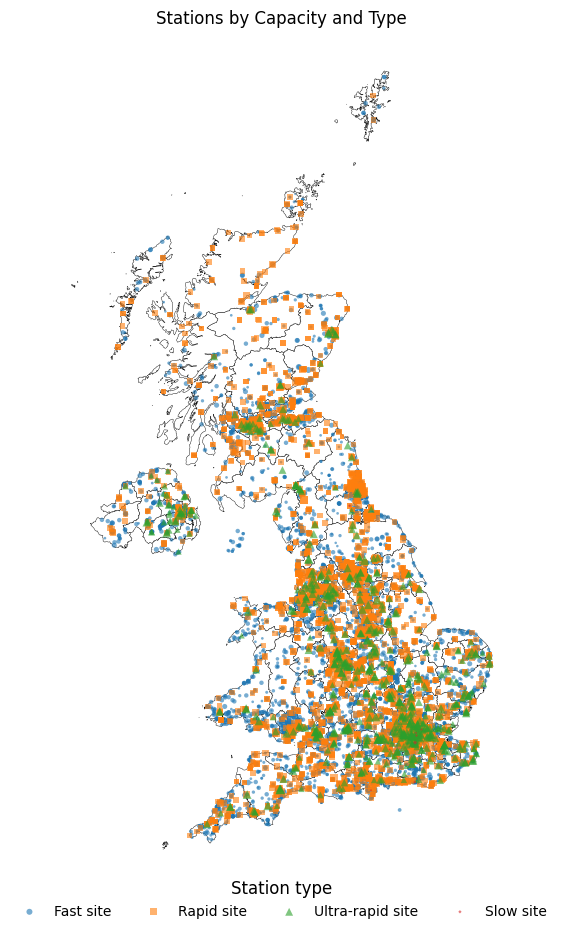

In [15]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 10))

regions.plot(
    ax=ax,
    legend=False,
    edgecolor="black",
    linewidth=0.3,
    facecolor="white",
)

def radius_from_capacity1(cap):
    cap = max(float(cap), 1.0)
    norm = np.log10(cap) / np.log10(2580)
    norm = norm ** 1.0
    min_r = 0.6
    max_r = 6
    return min_r + norm * (max_r - min_r)

sample = stations_uk_gdf.sample(frac=1, random_state=0).copy()

sample["size"] = sample["capacity"].apply(
    lambda c: radius_from_capacity1(c) ** 2
)

type_col = "type"  

types = sample[type_col].unique()

markers = ["o", "s", "^", "D", "P", "X", "v", "<", ">"]

for t, marker in zip(types, markers):
    sub = sample[sample[type_col] == t]
    ax.scatter(
        sub["lon"],
        sub["lat"],
        s=sub["size"],
        marker=marker,
        edgecolor="none",
        alpha=0.6,
        label=str(t),   # 图例里显示的名字
    )

ax.set_title("Stations by Capacity and Type")

ax.legend(
    title="Station type",
    loc="lower center",
    bbox_to_anchor=(0.5, -0.05),
    ncol=4,
    frameon=False,
    fontsize=10,
    title_fontsize=12,
    markerscale=1.0,     
)


plt.tight_layout(rect=[0, 0.06, 1, 1])
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_xticks([])
ax.set_yticks([])
plt.show()


### 4 subfigures for charging stations

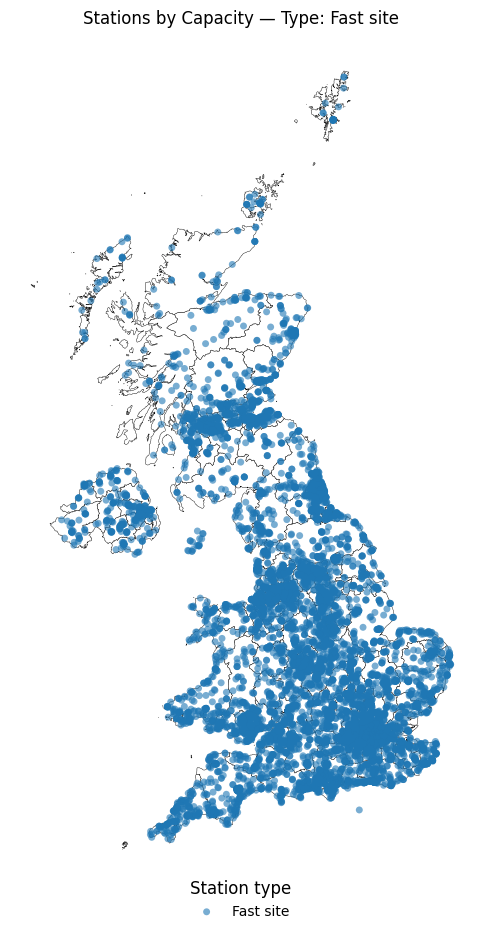

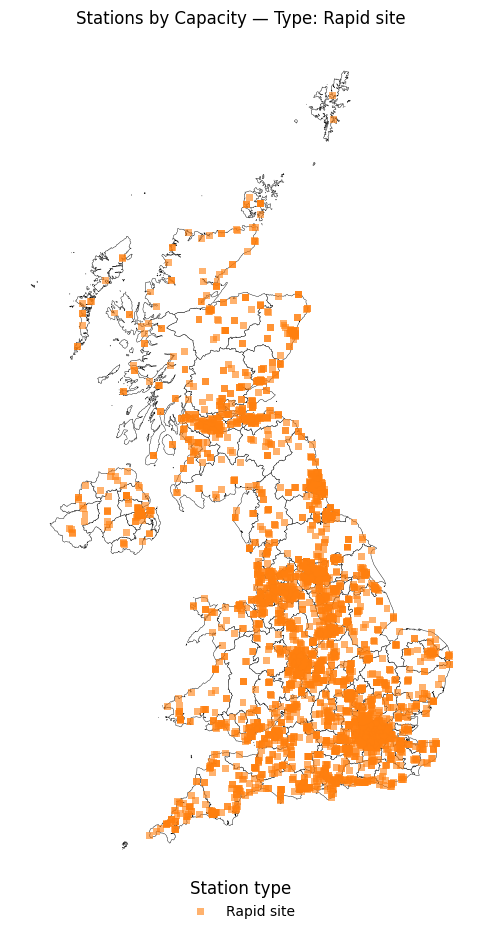

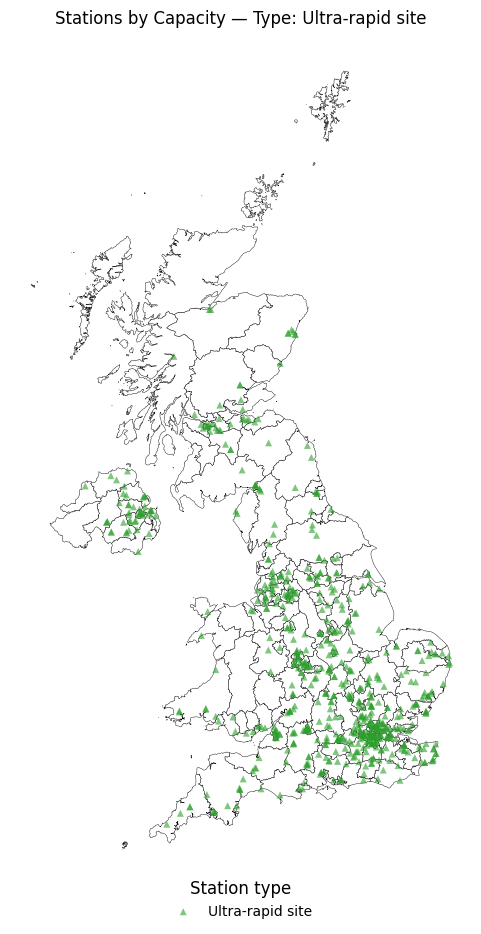

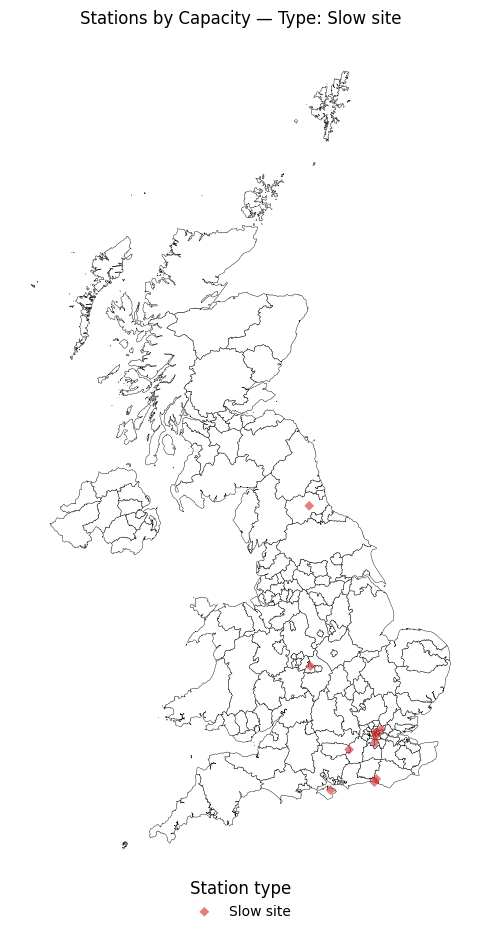

In [16]:
def radius_from_capacity2(cap):
    cap = max(float(cap), 1.0)
    norm = np.log10(cap) / np.log10(2580)
    norm = norm ** 1.0
    min_r = 0.6
    max_r = 6
    return min_r + norm * (max_r - min_r)

type_col = "type"

UNIFORM_SIZE = 25

sample = stations_uk_gdf.sample(frac=1, random_state=0).copy()
# sample["size"] = sample["capacity"].apply(lambda c: radius_from_capacity2(c) ** 2)
sample["size"] = UNIFORM_SIZE

types = list(sample[type_col].dropna().unique())

markers = ["o", "s", "^", "D", "P", "X", "v", "<", ">"]
marker_map = {t: markers[i % len(markers)] for i, t in enumerate(types)}

colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]  # matplotlib默认色板
color_map = {t: colors[i % len(colors)] for i, t in enumerate(types)}

for t in types:
    fig, ax = plt.subplots(figsize=(8, 10))

    regions.plot(
        ax=ax,
        legend=False,
        edgecolor="black",
        linewidth=0.3,
        facecolor="white",
    )

    sub = sample[sample[type_col] == t]

    ax.scatter(
        sub["lon"],
        sub["lat"],
        s=sub["size"],
        marker=marker_map[t],     # 改这里：复用形状
        c=color_map[t],           # 新增：复用颜色
        edgecolor="none",
        alpha=0.6,
        label=str(t),
    )

    ax.set_title(f"Stations by Capacity — Type: {t}")

    ax.legend(
        title="Station type",
        loc="lower center",
        bbox_to_anchor=(0.5, -0.05),
        ncol=1,
        frameon=False,
        fontsize=10,
        title_fontsize=12,
        markerscale=1.0,
    )

    plt.tight_layout(rect=[0, 0.06, 1, 1])
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_xticks([])
    ax.set_yticks([])
    plt.show()


## Aggregate by NUTS3

In [17]:
stations_with_regions = gpd.sjoin(stations_uk_gdf, regions, how="left", predicate="within")
stations_with_regions[['id', 'NUTS_NAME']]
stations_with_regions

,id,lon,lat,capacity,geometry,type,index_right,NUTS_ID,LEVL_CODE,CNTR_CODE,NAME_LATN,NUTS_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE
0,478722,-0.512255,51.961533,6000.0,POINT (-0.51225 51.96153),Ultra-rapid site,1172.0,UKH25,3.0,UK,Central Bedfordshire,Central Bedfordshire,4.0,1.0,3.0
1,478135,-0.172908,51.492988,44.0,POINT (-0.17291 51.49299),Fast site,1415.0,UKI33,3.0,UK,Kensington & Chelsea and Hammersmith & Fulham,Kensington & Chelsea and Hammersmith & Fulham,4.0,1.0,1.0
2,474932,-5.981143,54.671214,44.0,POINT (-5.98114 54.67121),Fast site,1435.0,UKN0D,3.0,UK,Antrim and Newtownabbey,Antrim and Newtownabbey,4.0,2.0,1.0
3,474931,-6.393026,54.444585,44.0,POINT (-6.39303 54.44459),Fast site,1135.0,UKN07,3.0,UK,"Armagh City, Banbridge and Craigavon","Armagh City, Banbridge and Craigavon",4.0,2.0,2.0
4,474298,-2.664842,53.471146,300.0,POINT (-2.66484 53.47115),Rapid site,1459.0,UKD71,3.0,UK,East Merseyside,East Merseyside,4.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26954,4126,-1.858056,53.716684,56.0,POINT (-1.85806 53.71668),Rapid site,1363.0,UKE44,3.0,UK,Calderdale and Kirklees,Calderdale and Kirklees,4.0,1.0,3.0
26955,4125,-2.672941,53.747227,68.5,POINT (-2.67294 53.74723),Rapid site,1383.0,UKD45,3.0,UK,Mid Lancashire,Mid Lancashire,4.0,1.0,1.0
26956,4124,-5.968309,54.571881,50.0,POINT (-5.96831 54.57188),Rapid site,1442.0,UKN06,3.0,UK,Belfast,Belfast,4.0,1.0,1.0
26957,4123,-3.173333,55.875053,64.0,POINT (-3.17333 55.87505),Rapid site,1465.0,UKM73,3.0,UK,East Lothian and Midlothian,East Lothian and Midlothian,4.0,1.0,1.0


In [18]:
cs_region_map = stations_with_regions.set_index('id')['NUTS_NAME'].to_dict()
stations_gdf = stations_uk_gdf.copy()
stations_gdf = stations_gdf[['id', 'capacity']]
stations_gdf['Region'] = stations_uk_gdf['id'].map(cs_region_map)


stations_gdf.rename(columns={'id': 'CS_ID', 'capacity': 'Capacity_kW'}, inplace=True)

stations_gdf

,CS_ID,Capacity_kW,Region
0,478722,6000.0,Central Bedfordshire
1,478135,44.0,Kensington & Chelsea and Hammersmith & Fulham
2,474932,44.0,Antrim and Newtownabbey
3,474931,44.0,"Armagh City, Banbridge and Craigavon"
4,474298,300.0,East Merseyside
...,...,...,...
26954,4126,56.0,Calderdale and Kirklees
26955,4125,68.5,Mid Lancashire
26956,4124,50.0,Belfast
26957,4123,64.0,East Lothian and Midlothian


In [19]:
cs_capacity_by_region = (
    stations_gdf
    .groupby('Region')['Capacity_kW']
    .sum()
)

regions_cs_Capacity = regions.merge(
    cs_capacity_by_region,
    left_on='NUTS_NAME',
    right_on='Region',
    how='left',
)

regions_cs_Capacity[regions_cs_Capacity['Capacity_kW'] == 0]

,NUTS_ID,LEVL_CODE,CNTR_CODE,NAME_LATN,NUTS_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,geometry,Capacity_kW


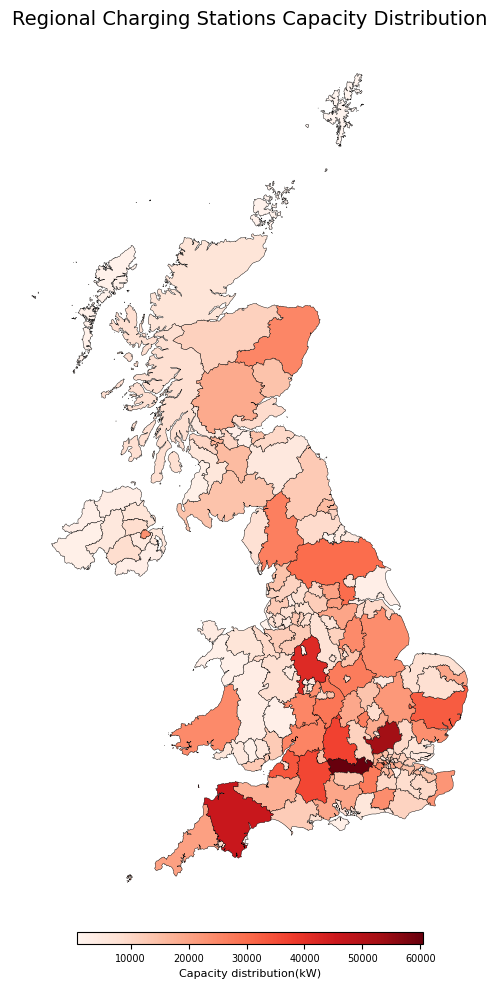

In [20]:
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.cm as cm

fig, ax = plt.subplots(figsize=(8, 10))

regions_cs_Capacity.plot(
    column='Capacity_kW',
    ax=ax,
    legend=False,
    cmap='Reds',
    edgecolor='black',
    linewidth=0.3,
    missing_kwds={"color": "lightgrey", "hatch": "///", "label": "No load data"}
)

ax.set_title("Regional Charging Stations Capacity Distribution", fontsize=14)
ax.set_axis_off()

vmin = regions_cs_Capacity['Capacity_kW'].min()
vmax = regions_cs_Capacity['Capacity_kW'].max()

norm = colors.Normalize(vmin=vmin, vmax=vmax)
sm = cm.ScalarMappable(norm=norm, cmap='Reds')
sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=ax,
    orientation='horizontal',
    fraction=0.02,    # 更薄
    pad=0.01,         # 更靠近
    shrink=0.45,      # 缩短长度
    aspect=30         # 拉长但更细
)

cbar.set_label('Capacity distribution(kW)', fontsize=8)
cbar.ax.tick_params(labelsize=7)

plt.tight_layout()
plt.show()

In [21]:
regions_cs_Capacity[["NUTS_NAME", "Capacity_kW"]] \
    .sort_values("Capacity_kW", ascending=False) \
    .head(20)

,NUTS_NAME,Capacity_kW
110,Berkshire,60505.70
9,Hertfordshire,53193.70
164,Devon CC,46250.70
160,Staffordshire CC,41755.80
49,Oxfordshire,37021.00
136,Wiltshire CC,36206.00
69,"Bath and North East Somerset, North Somerset a...",33828.20
81,Suffolk,32722.74
55,North Yorkshire CC,29919.00
57,Warwickshire,28266.20


## map to buses

In [22]:
import geopandas as gpd
from shapely.geometry import Point

Buses = pd.read_csv('./Buses.csv')
buses_geometry = [Point(xy) for xy in zip(Buses['x'], Buses['y'])]

gdf_buses = gpd.GeoDataFrame(Buses, geometry=buses_geometry, crs="EPSG:4326")
gdf_buses

,BusID,bus_name,voltage,x,y,RegionName,color,geometry
0,1,GB1-220,220.0,-2.895746,58.256815,NaN,red,POINT (-2.89575 58.25681)
1,2,GB10-275,275.0,-3.719714,56.088133,Devonside,green,POINT (-3.71971 56.08813)
2,3,GB11-275,275.0,-3.179692,55.924620,Whitehouse,red,POINT (-3.17969 55.92462)
3,4,GB12-275,275.0,-3.178627,55.903134,Kaimes,red,POINT (-3.17863 55.90313)
4,5,GB13-400,400.0,-2.938918,55.884694,Cockenzie,green,POINT (-2.93892 55.88469)
...,...,...,...,...,...,...,...,...
547,548,way/23281217,NaN,0.975236,51.105943,Added,red,POINT (0.97524 51.10594)
548,549,way/375626500,NaN,0.975236,51.105943,Added,red,POINT (0.97524 51.10594)
549,550,way/536905500,NaN,-3.050364,53.236592,Added,red,POINT (-3.05036 53.23659)
550,551,way/636630368,NaN,-1.194313,50.818144,Added,red,POINT (-1.19431 50.81814)


In [23]:
stations_uk_gdf

,id,lon,lat,capacity,geometry,type
0,478722,-0.512255,51.961533,6000.0,POINT (-0.51225 51.96153),Ultra-rapid site
1,478135,-0.172908,51.492988,44.0,POINT (-0.17291 51.49299),Fast site
2,474932,-5.981143,54.671214,44.0,POINT (-5.98114 54.67121),Fast site
3,474931,-6.393026,54.444585,44.0,POINT (-6.39303 54.44459),Fast site
4,474298,-2.664842,53.471146,300.0,POINT (-2.66484 53.47115),Rapid site
...,...,...,...,...,...,...
26954,4126,-1.858056,53.716684,56.0,POINT (-1.85806 53.71668),Rapid site
26955,4125,-2.672941,53.747227,68.5,POINT (-2.67294 53.74723),Rapid site
26956,4124,-5.968309,54.571881,50.0,POINT (-5.96831 54.57188),Rapid site
26957,4123,-3.173333,55.875053,64.0,POINT (-3.17333 55.87505),Rapid site


In [24]:
buses_m = gdf_buses.to_crs("EPSG:27700")
cs_m = stations_uk_gdf.to_crs("EPSG:27700")

cs_to_bus = gpd.sjoin_nearest(
    cs_m,
    buses_m[["BusID", "bus_name", "voltage", "RegionName", "geometry"]],
    how="left",
    distance_col="dist_m"
)

cs_to_bus = cs_to_bus.drop(columns=["index_right"])
cs_to_bus["dist_km"] = cs_to_bus["dist_m"] / 1000

cs_with_bus = cs_to_bus.to_crs("EPSG:4326")
cs_with_bus.rename(columns={
    'id': 'CS_ID',
    'capacity': 'Capacity_kW',
    'type': 'Station_Type',
    "BusID": "Bus_ID",
    "bus_name": "Bus_Name",
    "voltage": "Voltage_kV",
}, inplace=True)

cs_with_bus = cs_with_bus[[
    'CS_ID',
    'Capacity_kW',
    'Station_Type',
    'Bus_ID',
    'Bus_Name',
    'Voltage_kV',]]

cs_with_bus

,CS_ID,Capacity_kW,Station_Type,Bus_ID,Bus_Name,Voltage_kV
0,478722,6000.0,Ultra-rapid site,94,relation/7650368-400,400.0
1,478135,44.0,Fast site,67,GB72-400,400.0
2,474932,44.0,Fast site,219,way/166764802-275,275.0
3,474931,44.0,Fast site,241,way/227767019-275,275.0
4,474298,300.0,Rapid site,337,way/367005272-275,275.0
...,...,...,...,...,...,...
26954,4126,56.0,Rapid site,19,GB26-275,275.0
26955,4125,68.5,Rapid site,108,relation/7894975-400,400.0
26956,4124,50.0,Rapid site,219,way/166764802-275,275.0
26957,4123,64.0,Rapid site,288,way/27163121-275,275.0


In [25]:
df_cs_bus_ = cs_with_bus.rename(columns={
    "CS_ID": "StationID",
    "Bus_ID": "BusID",
    "Bus_Name": "BusName",
})

df_st_bus = df_st.merge(
    df_cs_bus_[["StationID", "BusID", "BusName", "Voltage_kV"]],
    on="StationID",
    how="left",
)

df_st_bus[["StationID", "BusID", "BusName"]].head()


,StationID,BusID,BusName
0,194240,527,way/204256468
1,194241,131,way/105304263-275
2,155229,407,way/76468460-275
3,256446,539,way/250962683
4,194034,535,way/94070118


In [26]:
df_conn_bus = df_conn_exp.merge(
    df_st_bus[["StationID", "BusID", "BusName", "Voltage_kV"]],
    on="StationID",
    how="left",
)
cols_to_drop = ["ConnectionType", "CurrentType"]

df_conn_bus = df_conn_bus.drop(
    columns=[c for c in cols_to_drop if c in df_conn_bus.columns]
)

# df_conn_bus.to_csv("UK_OCM_connectors_expanded_with_bus.csv", index=False)


In [27]:
LAD_UK = "./Local_Authority_Districts_May_2024_Boundaries_UK_BFE_-5285665645137523111.geojson"

station_cols = ["StationID", "Longitude", "Latitude"]
st = df_conn_bus[station_cols].dropna().drop_duplicates(subset=["StationID"]).copy()

# UK rough bounding box

g_st = gpd.GeoDataFrame(
    st,
    geometry=gpd.points_from_xy(st["Longitude"], st["Latitude"]),
    crs="EPSG:4326"
)

g_st = g_st[
    (g_st["Longitude"] > -8.5) &
    (g_st["Longitude"] < 2.5) &
    (g_st["Latitude"] > 49.5) &
    (g_st["Latitude"] < 61.5)
]


g_lad = gpd.read_file(LAD_UK)

if g_lad.crs is None:
    g_lad = g_lad.set_crs("EPSG:4326")

g_lad = g_lad.to_crs("EPSG:4326")

keep_cols = [c for c in ["LAD24CD", "LAD24NM", "CTRY24CD", "CTRY24NM"] if c in g_lad.columns]
g_lad_small = g_lad[keep_cols + ["geometry"]].copy()

matched = gpd.sjoin(g_st, g_lad_small, how="left", predicate="intersects")

lad_cols = ["StationID"] + keep_cols

for col in ["LAD24CD", "LAD24NM"]:
    if col in df_conn_bus.columns:
        df_conn_bus = df_conn_bus.drop(columns=col)

df_conn_bus = df_conn_bus.merge(
    matched[lad_cols],
    on="StationID",
    how="left"
)

df_conn_bus = df_conn_bus[df_conn_bus["LAD24CD"].notna()] # get rid of isle of man


In [28]:
ENGLAND_LSOA = "./Lower_layer_Super_Output_Areas_December_2021_Boundaries_EW_BFE_V10_5330842453253215289.geojson"
NORTH_IRELAND_LSOA = "./geography-dz2021-geojson/DZ2021.geojson"
SCOTLAND_LSOA = "./SG_DataZoneBdry_2022/SG_DataZone_Bdry_2022.shp"

england_lsoa = gpd.read_file(ENGLAND_LSOA)
ni_lsoa = gpd.read_file(NORTH_IRELAND_LSOA)
scotland_lsoa = gpd.read_file(SCOTLAND_LSOA)

TARGET_CRS = "EPSG:27700"

In [29]:
if england_lsoa.crs != TARGET_CRS:
    england_lsoa = england_lsoa.to_crs(TARGET_CRS)

if scotland_lsoa.crs != TARGET_CRS:
    scotland_lsoa = scotland_lsoa.to_crs(TARGET_CRS)

# NI is 4326 -> 27700
ni_lsoa = ni_lsoa.to_crs(TARGET_CRS)

england_lsoa = england_lsoa.assign(
    lsoa_code=england_lsoa["LSOA21CD"].astype(str),
    region="EW"
)[["lsoa_code", "region", "geometry"]]

scotland_lsoa = scotland_lsoa.assign(
    lsoa_code=scotland_lsoa["dzcode"].astype(str),
    region="SC"
)[["lsoa_code", "region", "geometry"]]

ni_lsoa = ni_lsoa.assign(
    lsoa_code=ni_lsoa["DZ2021_cd"].astype(str),
    region="NI"
)[["lsoa_code", "region", "geometry"]]

uk_lsoa = gpd.GeoDataFrame(
    pd.concat([england_lsoa, scotland_lsoa, ni_lsoa], ignore_index=True),
    crs=TARGET_CRS
)

In [30]:
invalid_mask = ~uk_lsoa.is_valid
uk_lsoa.loc[invalid_mask, "geometry"] = uk_lsoa.loc[invalid_mask, "geometry"].buffer(0)
uk_lsoa

,lsoa_code,region,geometry
0,E01000001,EW,"POLYGON ((532151.538 181867.433, 532152.5 1818..."
1,E01000002,EW,"POLYGON ((532634.497 181926.016, 532632.048 18..."
2,E01000003,EW,"POLYGON ((532153.703 182165.155, 532158.25 182..."
3,E01000005,EW,"POLYGON ((533619.062 181402.364, 533639.868 18..."
4,E01000006,EW,"POLYGON ((545126.852 184310.838, 545145.213 18..."
...,...,...,...
46839,N20003776,NI,"MULTIPOLYGON (((170107.583 504381.049, 170115...."
46840,N20003777,NI,"MULTIPOLYGON (((170071.23 504439.6, 170115.329..."
46841,N20003778,NI,"MULTIPOLYGON (((170178.979 503909.159, 170141...."
46842,N20003779,NI,"MULTIPOLYGON (((169936.664 503323.603, 169934...."


In [31]:
bus_gdf = gpd.GeoDataFrame(
    df_conn_bus.copy(),
    geometry=gpd.points_from_xy(df_conn_bus["Longitude"], df_conn_bus["Latitude"]),
    crs="EPSG:4326"
).to_crs(TARGET_CRS)

uk_lsoa = uk_lsoa.to_crs(TARGET_CRS)

bus_with_lsoa = gpd.sjoin(
    bus_gdf,
    uk_lsoa[["lsoa_code", "region", "geometry"]],
    how="left",
    predicate="within"  # 点在面内
).drop(columns=["index_right"])

In [32]:
df_conn_bus = bus_with_lsoa.drop(columns="geometry")

missing = df_conn_bus["lsoa_code"].isna()

print("Unmatched before fix:", missing.sum())

if missing.any():

    g_missing = gpd.GeoDataFrame(
        df_conn_bus.loc[missing, ["StationID","Longitude","Latitude"]],
        geometry=gpd.points_from_xy(
            df_conn_bus.loc[missing,"Longitude"],
            df_conn_bus.loc[missing,"Latitude"]
        ),
        crs="EPSG:4326"
    ).to_crs(TARGET_CRS)

    nearest = gpd.sjoin_nearest(
        g_missing,
        uk_lsoa[["lsoa_code","region","geometry"]],
        how="left",
    )

    df_conn_bus.loc[missing, "lsoa_code"] = nearest["lsoa_code"].values
    df_conn_bus.loc[missing, "region"] = nearest["region"].values

print("Unmatched after fix:", df_conn_bus["lsoa_code"].isna().sum())

df_conn_bus.to_csv("UK_OCM_connectors_expanded_with_bus_and_LAD_LSOA.csv", index=False)

Unmatched before fix: 6
Unmatched after fix: 0
